# What are the Most Optimal Skills for Data Engineers?

## Objective

Identify Data Engineering skills that combine strong job-market demand with higher median salaries in the United States.

## Methodology

1. Filter U.S. Data Engineer job postings
2. Remove postings without salary data
3. Explode skills into individual rows
4. Calculate skill demand and median salary
5. Convert skill demand into percentage of Data Engineer postings
6. Keep skills with meaningful market demand
7. Map each skill to its technology category
8. Visualize demand vs. salary using a Seaborn scatter plot

In [2]:
# ============================================
# Import libraries, load, clean, and filter data
# ============================================

import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from datasets import load_dataset
from adjustText import adjust_text

# Load dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Convert posting date into datetime format
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Convert job_skills from text into real Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Keep only U.S. Data Engineer job postings
df_DE_US = df[
    (df["job_title_short"] == "Data Engineer") &
    (df["job_country"] == "United States")
].copy()

# Remove rows without yearly salary data
df_DE_US = df_DE_US.dropna(
    subset=["salary_year_avg"]
)

# Quick check that everything loaded correctly
df_DE_US.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."
307,Data Engineer,Data Engineer,"Austin, TX",via LinkedIn,Full-time,False,"New York, United States",2023-10-03 13:05:31,False,False,United States,year,185000.0,NaN,hackajob,"[nosql, sql]","{'programming': ['nosql', 'sql']}"
339,Data Engineer,Global Market Leading Energy Firm - Staff Data...,United States,via LinkedIn,Full-time,False,"California, United States",2023-09-22 13:07:57,False,False,United States,year,195000.0,NaN,Xcede,NaN,NaN
380,Data Engineer,Snaplogic Data Engineer,"Durham, NC",via LinkedIn,Full-time,False,"Illinois, United States",2023-08-16 13:26:21,True,False,United States,year,97500.0,NaN,KTek Resourcing,"[sql, python]","{'programming': ['sql', 'python']}"


In [3]:
# ============================================
# Prepare U.S. Data Engineer skill data
# ============================================

# Keep only U.S. Data Engineer job postings
df_DE_US = df[
    (df["job_title_short"] == "Data Engineer") &
    (df["job_country"] == "United States")
].copy()

# Remove jobs without yearly salary information
df_DE_US = df_DE_US.dropna(subset=["salary_year_avg"])

# One skill per row
# Example: ['sql', 'python', 'aws'] -> three separate rows
df_DE_US_exploded = df_DE_US.explode("job_skills")

# Preview salary + skill combinations
df_DE_US_exploded[
    ["salary_year_avg", "job_skills"]
].head()

,salary_year_avg,job_skills
92,120000.0,sql
92,120000.0,python
146,129500.0,golang
146,129500.0,scala
146,129500.0,python


In [4]:
# ============================================
# Calculate statistics for each skill
# ============================================

# Group by skill and calculate:
# skill_count   = number of postings mentioning the skill
# median_salary = typical yearly salary associated with the skill
df_DE_skills = (
    df_DE_US_exploded
    .groupby("job_skills")
    .agg(
        skill_count=("job_skills", "count"),
        median_salary=("salary_year_avg", "median")
    )
)

# Convert raw skill count into % of Data Engineer jobs
# This makes demand easier to interpret than raw counts
df_DE_skills["skill_percent"] = (
    df_DE_skills["skill_count"]
    / len(df_DE_US)
    * 100
)

# Sort highest demand first
df_DE_skills = df_DE_skills.sort_values(
    by="skill_percent",
    ascending=False
)

df_DE_skills.head(10)

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2110,125000.00000,72.384220
python,2007,127794.50000,68.850772
aws,1313,131000.00000,45.042882
spark,968,137410.15625,33.207547
azure,961,125000.00000,32.967410
snowflake,765,130700.00000,26.243568
java,732,137000.00000,25.111492
kafka,536,145000.00000,18.387650
nosql,519,140000.00000,17.804460


In [5]:
# ============================================
# Keep skills with meaningful demand
# ============================================

# Only keep skills appearing in at least 5%
# of U.S. Data Engineer job postings
min_demand = 5

df_DE_skills_high_demand = df_DE_skills[
    df_DE_skills["skill_percent"] >= min_demand
].copy()

df_DE_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2110,125000.00000,72.384220
python,2007,127794.50000,68.850772
aws,1313,131000.00000,45.042882
spark,968,137410.15625,33.207547
azure,961,125000.00000,32.967410
snowflake,765,130700.00000,26.243568
java,732,137000.00000,25.111492
kafka,536,145000.00000,18.387650
nosql,519,140000.00000,17.804460


In [6]:
# ============================================
# Build skill -> technology category lookup
# ============================================

technology_rows = []

# job_type_skills contains dictionaries such as:
# {'programming': ['python', 'sql'], 'cloud': ['aws', 'azure']}
for item in df["job_type_skills"].dropna():

    # Convert text dictionary into an actual Python dictionary if needed
    skill_dict = (
        ast.literal_eval(item)
        if isinstance(item, str)
        else item
    )

    # Loop through each technology category and its skills
    for technology, skills in skill_dict.items():

        # Add one row for every skill
        for skill in skills:
            technology_rows.append(
                {
                    "technology": technology,
                    "skills": skill
                }
            )

# Convert rows into a DataFrame
df_technology = (
    pd.DataFrame(technology_rows)
    .drop_duplicates()
)

df_technology.head()

,technology,skills
0,analyst_tools,power bi
1,analyst_tools,tableau
2,programming,r
3,programming,python
4,programming,sql


In [7]:
# ============================================
# Add technology category to each skill
# ============================================

df_plot = (
    df_DE_skills_high_demand
    .reset_index()
    .merge(
        df_technology,
        left_on="job_skills",    # Skill from our analysis
        right_on="skills",       # Skill from technology lookup
        how="left"
    )
)

# Remove duplicate skill mappings if necessary
df_plot = df_plot.drop_duplicates(
    subset=["job_skills"]
)

df_plot.head(10)

,job_skills,skill_count,median_salary,skill_percent,technology,skills
0,sql,2110,125000.00000,72.384220,programming,sql
1,python,2007,127794.50000,68.850772,programming,python
2,aws,1313,131000.00000,45.042882,cloud,aws
3,spark,968,137410.15625,33.207547,libraries,spark
4,azure,961,125000.00000,32.967410,cloud,azure
5,snowflake,765,130700.00000,26.243568,cloud,snowflake
6,java,732,137000.00000,25.111492,programming,java
7,kafka,536,145000.00000,18.387650,libraries,kafka
8,nosql,519,140000.00000,17.804460,programming,nosql
9,redshift,514,135000.00000,17.632933,cloud,redshift


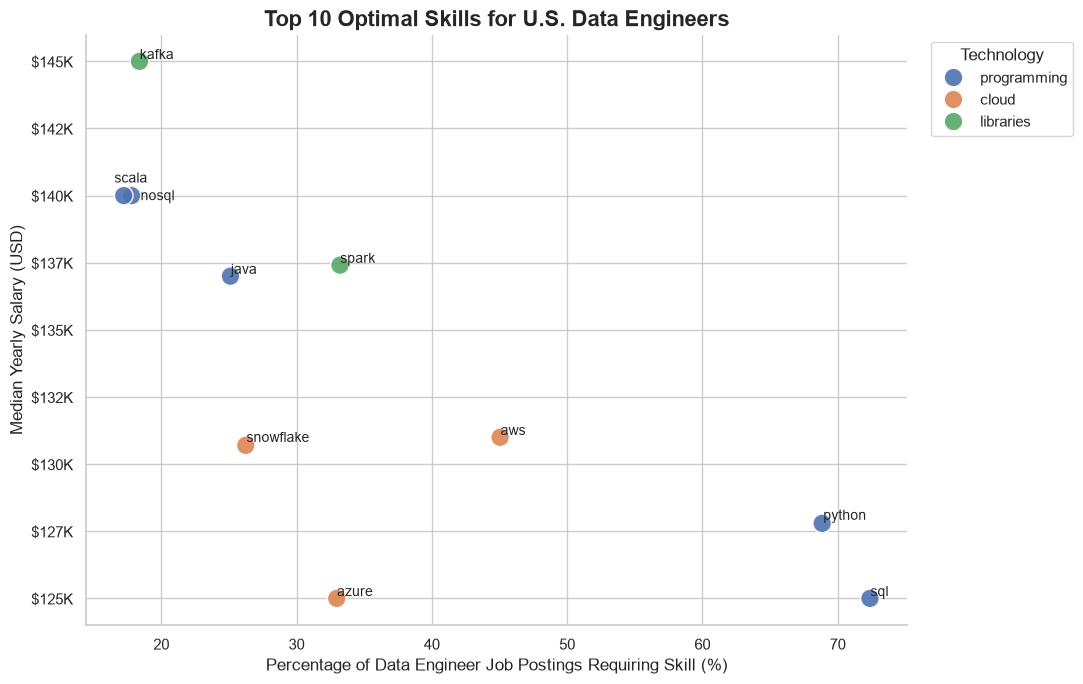

In [9]:
# ============================================
# Create a cleaner Top 10 optimal skills chart
# ============================================

# Create a simple score combining demand + salary
# Higher score = stronger combination of market demand and pay
df_plot["opportunity_score"] = (
    df_plot["skill_percent"]
    * df_plot["median_salary"]
)

# Keep only the Top 10 skills by opportunity score
df_top10 = (
    df_plot
    .sort_values("opportunity_score", ascending=False)
    .head(10)
    .copy()
)

# Clean Seaborn styling
sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 7))

# Scatterplot
sns.scatterplot(
    data=df_top10,
    x="skill_percent",          # Demand
    y="median_salary",          # Salary
    hue="technology",           # Technology category
    s=180,                      # Larger points for readability
    alpha=0.9
)

# Add skill labels
texts = []

for _, row in df_top10.iterrows():
    texts.append(
        plt.text(
            row["skill_percent"],
            row["median_salary"],
            row["job_skills"],
            fontsize=10
        )
    )

# Move overlapping labels apart
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle="->",
        color="gray"
    )
)

# Title and axis labels
plt.title(
    "Top 10 Optimal Skills for U.S. Data Engineers",
    fontsize=16,
    weight="bold"
)

plt.xlabel(
    "Percentage of Data Engineer Job Postings Requiring Skill (%)"
)

plt.ylabel(
    "Median Yearly Salary (USD)"
)

# Format salary axis: 150000 -> $150K
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda y, _: f"${int(y / 1000)}K"
    )
)

# Put legend outside chart
plt.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

sns.despine()

plt.tight_layout()
plt.show()